In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gauravrawat99/road-accident-test/test.csv
/kaggle/input/datasets/gauravrawat99/road-accident-train/train.csv


In [2]:
import pandas as pd
train=pd.read_csv("/kaggle/input/datasets/gauravrawat99/road-accident-train/train.csv")
train

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [4]:
train.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [5]:
cat_cols = train.select_dtypes(include=object).columns

for col in cat_cols:
    print(f'======{col}=======')
    vc=train[col].value_counts(dropna=False)

    for category, count in vc.items():
        print(f'{category}:{count}')

======road_type=======
highway:173672
rural:172719
urban:171363
======lighting=======
dim:183826
daylight:178015
night:155913
======weather=======
foggy:181463
clear:179306
rainy:156985
======time_of_day=======
morning:173410
evening:172837
afternoon:171507


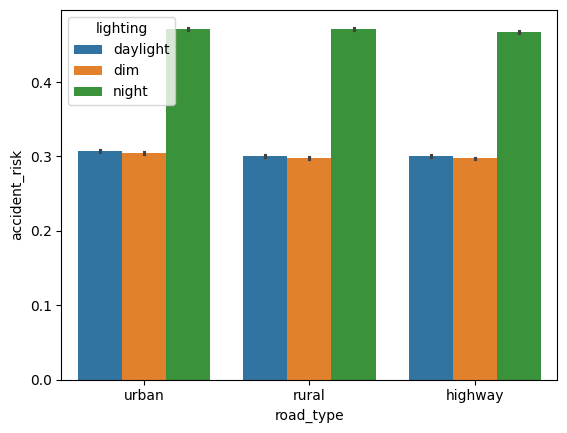

Number of accidents reported by different road type:
 road_type
highway    206531
rural      204172
urban      204373
Name: num_reported_accidents, dtype: int64


In [6]:
#Accident Numbers by road type  and lighting
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=train, x='road_type', y='accident_risk', hue='lighting')
plt.show()

print("Number of accidents reported by different road type:\n", train.groupby('road_type')['num_reported_accidents'].sum())

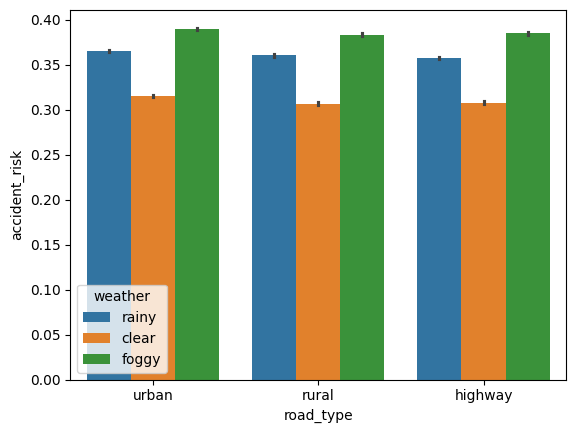

Number of accidents reported by different weather:
 weather
clear    204694
foggy    215800
rainy    194582
Name: num_reported_accidents, dtype: int64


In [7]:
##Accident Numbers by road type and weather
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=train, x='road_type', y='accident_risk', hue='weather')
plt.show()

print("Number of accidents reported by different weather:\n", train.groupby('weather')['num_reported_accidents'].sum())

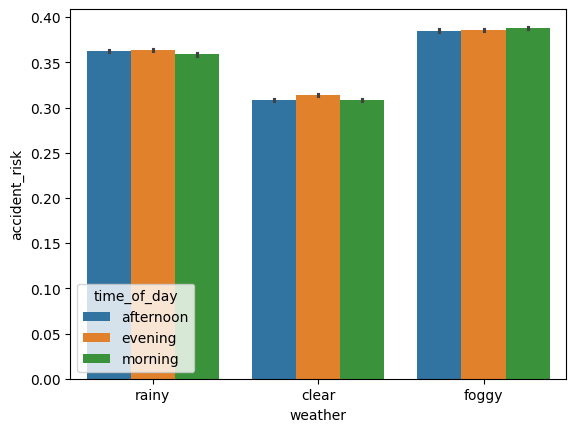

Number of accidents reported by different time of day:
 time_of_day
afternoon    204148
evening      205596
morning      205332
Name: num_reported_accidents, dtype: int64


In [8]:
##Accident Numbers by road type and weather
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=train, x='weather', y='accident_risk', hue='time_of_day')
plt.show()

print("Number of accidents reported by different time of day:\n", train.groupby('time_of_day')['num_reported_accidents'].sum())

## Model training

In [9]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [6]:
X=train.drop(['id', 'accident_risk'], axis=1)
y=train['accident_risk']

In [7]:
X

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...
517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2
517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1
517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0
517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3


In [8]:
#Feature engineering
X['lighting_time_risk']=X['lighting'] + '_' + X['time_of_day']

X['weather_curvature']=X['weather']+'_'+X['speed_limit'].astype(str)

X['road_lanes']=X['road_type']+'_'+X['num_lanes'].astype(str)

X['is_high_speed']=(X['speed_limit']>=60).astype(int)

X['is_sharpe_curve']=(X['curvature'] > X['curvature'].quantile(0.75)).astype(int)

X['danger_condition']=((X['weather'].isin(['rainy','foggy'])) & (X['lighting'].isin(['dim','night']))).astype(int)

X['accident_density']=X['num_reported_accidents'] / (X['num_lanes']+1)

X['accident_level']=pd.cut(X['num_reported_accidents'], bins=[-1,1,3,10], labels=['low','medium','high'])

X['no_sign_curve']=((~X['road_signs_present']) & (X['curvature'] > X['curvature'].median())).astype(int)

X['public_high_speed']=((X['public_road']) & (X['speed_limit'] > 50)).astype(int)

X['is_peak_time']=X['time_of_day'].isin(['morning','evening']).astype(int)

X['school_peak_risk']=((X['school_season']) & (X['time_of_day'].isin(['morning', 'afternoon']))).astype(int)

X['curvature_level']=pd.cut(X['curvature'], bins=5, labels=['very_low', 'low', 'medium', 'high', 'very_high'])

X['risk_score']=(X['is_high_speed']*2 + X['is_sharpe_curve']*2 + X['danger_condition']*3 + X['no_sign_curve']*2 + X['is_peak_time'])

for col in ['road_type', 'weather', 'lighting', 'time_of_day']:
    X[f'{col}_accident_mean']=X.groupby(col)['num_reported_accidents'].transform('mean')

In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   road_type                  517754 non-null  object  
 1   num_lanes                  517754 non-null  int64   
 2   curvature                  517754 non-null  float64 
 3   speed_limit                517754 non-null  int64   
 4   lighting                   517754 non-null  object  
 5   weather                    517754 non-null  object  
 6   road_signs_present         517754 non-null  bool    
 7   public_road                517754 non-null  bool    
 8   time_of_day                517754 non-null  object  
 9   holiday                    517754 non-null  bool    
 10  school_season              517754 non-null  bool    
 11  num_reported_accidents     517754 non-null  int64   
 12  lighting_time_risk         517754 non-null  object  
 13  weather_curvat

In [16]:
#Train catboost
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

cat_cols=X.select_dtypes(include=['object', 'category']).columns.tolist()

X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42)

train_pool=Pool(X_train, y_train, cat_features=cat_cols)
val_pool=Pool(X_val, y_val, cat_features=cat_cols)

model=CatBoostRegressor(depth=6, learning_rate=0.02, iterations=5000, l2_leaf_reg=3, eval_metric='AUC', early_stopping_rounds=200, thread_count=-1, random_seed=42, verbose=200).fit(train_pool, eval_set=val_pool)


0:	test: 0.6856910	best: 0.6856910 (0)	total: 720ms	remaining: 1h
200:	test: 0.6923680	best: 0.6923680 (200)	total: 1m 45s	remaining: 41m 52s
400:	test: 0.6925705	best: 0.6925705 (400)	total: 3m 17s	remaining: 37m 41s
600:	test: 0.6926293	best: 0.6926293 (600)	total: 4m 50s	remaining: 35m 26s
800:	test: 0.6926714	best: 0.6926714 (800)	total: 6m 25s	remaining: 33m 43s
1000:	test: 0.6926982	best: 0.6926982 (1000)	total: 8m	remaining: 31m 58s
1200:	test: 0.6927140	best: 0.6927140 (1200)	total: 9m 34s	remaining: 30m 18s
1400:	test: 0.6927231	best: 0.6927231 (1397)	total: 11m 6s	remaining: 28m 32s
1600:	test: 0.6927338	best: 0.6927338 (1600)	total: 12m 37s	remaining: 26m 49s
1800:	test: 0.6927426	best: 0.6927426 (1800)	total: 14m 8s	remaining: 25m 7s
2000:	test: 0.6927525	best: 0.6927525 (2000)	total: 15m 40s	remaining: 23m 29s
2200:	test: 0.6927602	best: 0.6927602 (2200)	total: 17m 12s	remaining: 21m 52s
2400:	test: 0.6927663	best: 0.6927663 (2400)	total: 18m 43s	remaining: 20m 16s
2600:	t

AttributeError: 'CatBoostRegressor' object has no attribute 'predict_proba'

In [18]:
from sklearn.metrics import mean_squared_error

val_pred=model.predict(val_pool)

print("R2 score: ", r2_score(y_val, val_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_val, val_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_val, val_pred)))

R2 score:  0.8851106313371706
Mean Absolute Error:  0.04373002947175295
RMSE:  0.05629391157420031


Index(['Feature Id', 'Importances'], dtype='object')


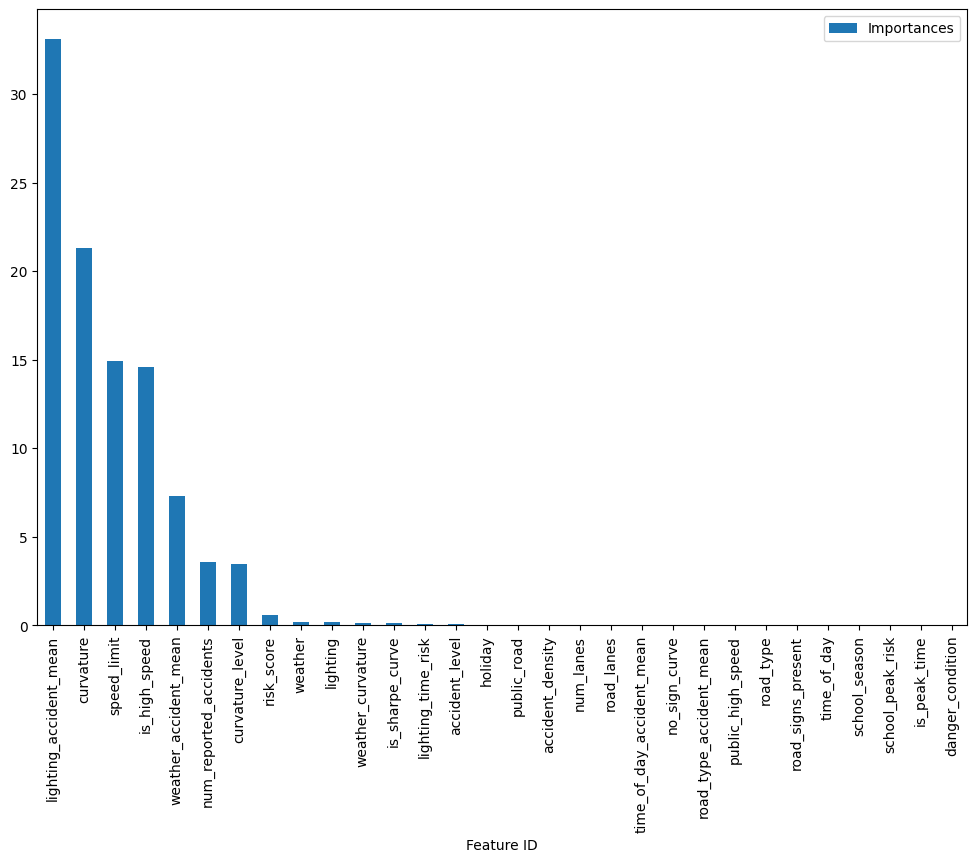

In [19]:
fi=model.get_feature_importance(prettified=True)
print(fi.columns)

# Rename generically
fi.columns = ['Feature ID', 'Importances']

fi = fi.sort_values('Importances', ascending=False)

import matplotlib.pyplot as plt

fi.plot(
    x='Feature ID',
    y='Importances',
    kind='bar',
    figsize=(12,8)
)
plt.show()

In [ ]:
#Training RandomForestRegressor
#To DO

## Test data with catboost settings

In [21]:
test=pd.read_csv('/kaggle/input/datasets/gauravrawat99/road-accident-test/test.csv')
test_ID=test['id']

#Feature engineering
test['lighting_time_risk']=test['lighting'] + '_' + test['time_of_day']

test['weather_curvature']=test['weather']+'_'+test['speed_limit'].astype(str)

test['road_lanes']=test['road_type']+'_'+test['num_lanes'].astype(str)

test['is_high_speed']=(test['speed_limit']>=60).astype(int)

test['is_sharpe_curve']=(test['curvature'] > test['curvature'].quantile(0.75)).astype(int)

test['danger_condition']=((test['weather'].isin(['rainy','foggy'])) & (test['lighting'].isin(['dim','night']))).astype(int)

test['accident_density']=test['num_reported_accidents'] / (test['num_lanes']+1)

test['accident_level']=pd.cut(test['num_reported_accidents'], bins=[-1,1,3,10], labels=['low','medium','high'])

test['no_sign_curve']=((~test['road_signs_present']) & (test['curvature'] > test['curvature'].median())).astype(int)

test['public_high_speed']=((test['public_road']) & (test['speed_limit'] > 50)).astype(int)

test['is_peak_time']=test['time_of_day'].isin(['morning','evening']).astype(int)

test['school_peak_risk']=((test['school_season']) & (test['time_of_day'].isin(['morning', 'afternoon']))).astype(int)

test['curvature_level']=pd.cut(test['curvature'], bins=5, labels=['very_low', 'low', 'medium', 'high', 'very_high'])

test['risk_score']=(test['is_high_speed']*2 + test['is_sharpe_curve']*2 + test['danger_condition']*3 + test['no_sign_curve']*2 + test['is_peak_time'])

for col in ['road_type', 'weather', 'lighting', 'time_of_day']:
    test[f'{col}_accident_mean']=test.groupby(col)['num_reported_accidents'].transform('mean')

In [22]:
from catboost import Pool
test=test[X.columns]

test_pool=Pool(data=test, cat_features=cat_cols)

test_probs=model.predict(test_pool)

print(test_probs)

[0.29179902 0.12496769 0.1876941  ... 0.24987954 0.12996572 0.48782635]


In [23]:
import pandas as pd

submission = pd.DataFrame({
    "id": test_ID,
    "accident_risk": test_probs
})

submission.to_csv("submission.csv", index=False)

print("submission.csv saved!")
print(f"Shape           : {submission.shape}")

submission.csv saved!
Shape           : (172585, 2)


### Random Forest Regressor

In [10]:
#Encoding cat cols
# cat_cols=X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded=pd.get_dummies(X)
X_encoded.columns.tolist()

['num_lanes',
 'curvature',
 'speed_limit',
 'road_signs_present',
 'public_road',
 'holiday',
 'school_season',
 'num_reported_accidents',
 'is_high_speed',
 'is_sharpe_curve',
 'danger_condition',
 'accident_density',
 'no_sign_curve',
 'public_high_speed',
 'is_peak_time',
 'school_peak_risk',
 'risk_score',
 'road_type_accident_mean',
 'weather_accident_mean',
 'lighting_accident_mean',
 'time_of_day_accident_mean',
 'road_type_highway',
 'road_type_rural',
 'road_type_urban',
 'lighting_daylight',
 'lighting_dim',
 'lighting_night',
 'weather_clear',
 'weather_foggy',
 'weather_rainy',
 'time_of_day_afternoon',
 'time_of_day_evening',
 'time_of_day_morning',
 'lighting_time_risk_daylight_afternoon',
 'lighting_time_risk_daylight_evening',
 'lighting_time_risk_daylight_morning',
 'lighting_time_risk_dim_afternoon',
 'lighting_time_risk_dim_evening',
 'lighting_time_risk_dim_morning',
 'lighting_time_risk_night_afternoon',
 'lighting_time_risk_night_evening',
 'lighting_time_risk_ni

In [11]:
X_encoded

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,is_high_speed,is_sharpe_curve,...,road_lanes_urban_3,road_lanes_urban_4,accident_level_low,accident_level_medium,accident_level_high,curvature_level_very_low,curvature_level_low,curvature_level_medium,curvature_level_high,curvature_level_very_high
0,2,0.06,35,False,True,False,True,1,0,0,...,False,False,True,False,False,True,False,False,False,False
1,4,0.99,35,True,False,True,True,0,0,1,...,False,True,True,False,False,False,False,False,False,True
2,4,0.63,70,False,True,True,False,2,1,0,...,False,False,False,True,False,False,False,False,True,False
3,4,0.07,35,True,True,False,False,1,0,0,...,False,False,True,False,False,True,False,False,False,False
4,1,0.58,60,False,False,True,False,1,1,0,...,False,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,4,0.10,70,True,True,False,False,2,1,0,...,False,False,False,True,False,True,False,False,False,False
517750,4,0.47,35,True,True,False,False,1,0,0,...,False,False,True,False,False,False,False,True,False,False
517751,4,0.62,25,False,False,False,True,0,0,0,...,False,True,True,False,False,False,False,False,True,False
517752,3,0.63,25,True,False,True,True,3,0,0,...,False,False,False,True,False,False,False,False,True,False


In [12]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 77 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   num_lanes                              517754 non-null  int64  
 1   curvature                              517754 non-null  float64
 2   speed_limit                            517754 non-null  int64  
 3   road_signs_present                     517754 non-null  bool   
 4   public_road                            517754 non-null  bool   
 5   holiday                                517754 non-null  bool   
 6   school_season                          517754 non-null  bool   
 7   num_reported_accidents                 517754 non-null  int64  
 8   is_high_speed                          517754 non-null  int64  
 9   is_sharpe_curve                        517754 non-null  int64  
 10  danger_condition                       517754 non-null  

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.decomposition import PCA

X_train, X_val, y_train, y_val = train_test_split(X_encoded, y, random_state=42)

# X_pca=PCA(n_components=0.95).fit_transform(X_train)

param_grid={'n_estimators':[25,50,100,150],
           'max_depth':[4,5,6,7]}

grid_search_rfr=GridSearchCV(RandomForestRegressor(n_jobs=-1), param_grid=param_grid, cv=5).fit(X_train, y_train)

grid_search_rfr_pred=grid_search_rfr.predict(X_val)
print("Best params: ", grid_search_rfr.best_params_)
print("R2 score: ", r2_score(y_val, grid_search_rfr_pred))
print('MAE: ', mean_absolute_error(y_val, grid_search_rfr_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_val, grid_search_rfr_pred)))

Best params:  {'max_depth': 7, 'n_estimators': 50}


NameError: name 'r2_score' is not defined

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

grid_search_rfr_pred=grid_search_rfr.predict(X_val)
print("Best params: ", grid_search_rfr.best_params_)
print("R2 score: ", r2_score(y_val, grid_search_rfr_pred))
print('MAE: ', mean_absolute_error(y_val, grid_search_rfr_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_val, grid_search_rfr_pred)))

Best params:  {'max_depth': 7, 'n_estimators': 50}
R2 score:  0.8590276245202195
MAE:  0.048137132155517834
RMSE:  0.06235747397238024


#### Catboost showed better results as compared to Random forest so considering catboost in this case